In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\Gouri\AppData\Local\Programs\Python\Python310\python.exe
3.10.4 (tags/v3.10.4:9d38120, Mar 23 2022, 23:13:41) [MSC v.1929 64 bit (AMD64)]


In [4]:
import sys
import subprocess

subprocess.run([sys.executable, "-m", "pip", "--version"])

CompletedProcess(args=['C:\\Users\\Gouri\\AppData\\Local\\Programs\\Python\\Python310\\python.exe', '-m', 'pip', '--version'], returncode=0)

In [2]:
import pandas as pd

df = pd.read_csv("European_Bank.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.tail()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,2025,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.describe

<bound method NDFrame.describe of       Year  CustomerId    Surname  CreditScore Geography  Gender  Age  Tenure  \
0     2025    15634602   Hargrave          619    France  Female   42       2   
1     2025    15647311       Hill          608     Spain  Female   41       1   
2     2025    15619304       Onio          502    France  Female   42       8   
3     2025    15701354       Boni          699    France  Female   39       1   
4     2025    15737888   Mitchell          850     Spain  Female   43       2   
...    ...         ...        ...          ...       ...     ...  ...     ...   
9995  2025    15606229   Obijiaku          771    France    Male   39       5   
9996  2025    15569892  Johnstone          516    France    Male   35      10   
9997  2025    15584532        Liu          709    France  Female   36       7   
9998  2025    15682355  Sabbatini          772   Germany    Male   42       3   
9999  2025    15628319     Walker          792    France  Female   28      

In [9]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.nunique()

Year                   1
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [15]:
df_clean = df.copy()

In [16]:
df_clean = df_clean.drop(columns=["Year", "CustomerId", "Surname"])

In [17]:
df_clean.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [18]:
df_clean.shape

(10000, 11)

In [19]:
df_clean["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [20]:
df_clean["Exited"].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

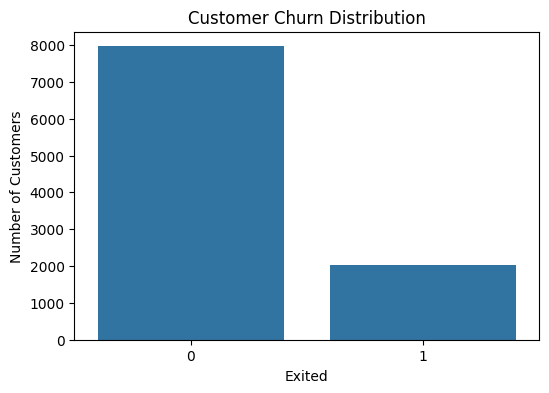

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df_clean)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
df_clean["Age"].describe()


count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

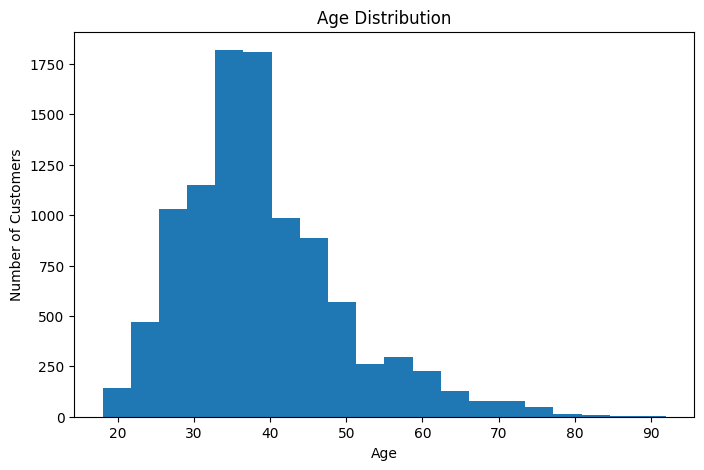

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

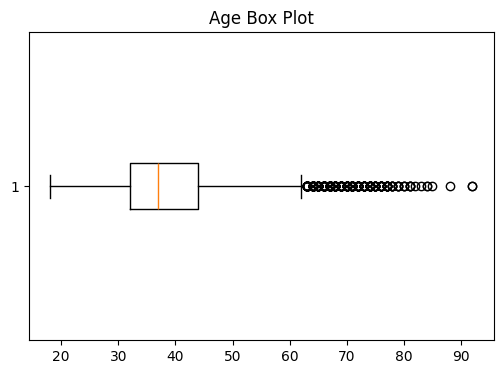

In [24]:
plt.figure(figsize=(6,4))

plt.boxplot(df_clean["Age"], vert=False)

plt.title("Age Box Plot")

plt.show()

In [25]:
df_clean["CreditScore"].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

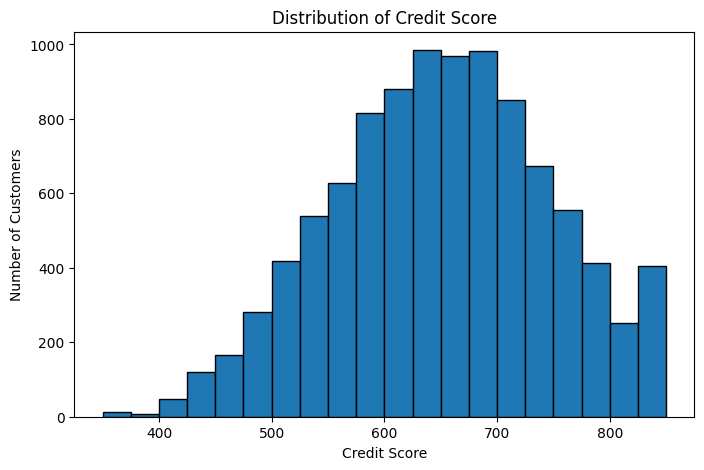

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["CreditScore"], bins=20, edgecolor="black")

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

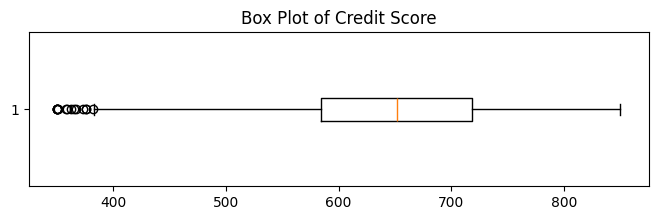

In [27]:
plt.figure(figsize=(8,2))

plt.boxplot(df_clean["CreditScore"], vert=False)

plt.title("Box Plot of Credit Score")

plt.show()

In [28]:
df_clean["Balance"].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

In [29]:
df_clean["EstimatedSalary"].describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64

In [30]:
df_clean["Tenure"].describe()

count    10000.000000
mean         5.012800
std          2.892174
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Tenure, dtype: float64

In [31]:
df_clean["NumOfProducts"].describe()

count    10000.000000
mean         1.530200
std          0.581654
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: NumOfProducts, dtype: float64

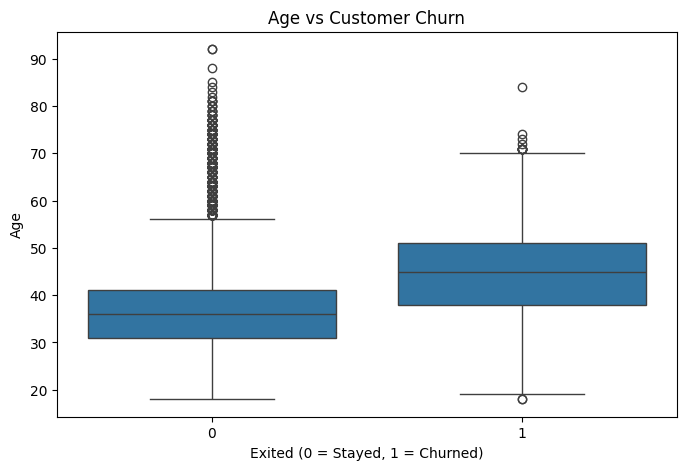

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Exited", y="Age", data=df_clean)

plt.title("Age vs Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Age")

plt.show()


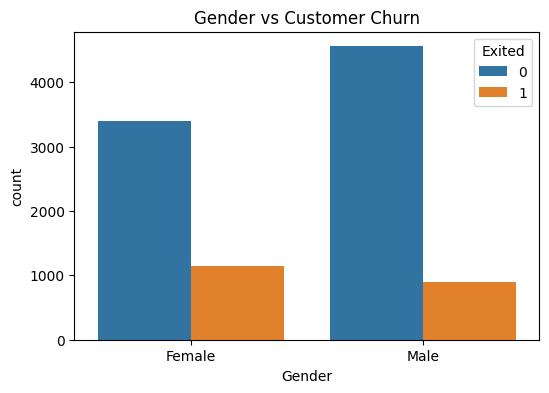

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", hue="Exited", data=df_clean)

plt.title("Gender vs Customer Churn")

plt.show()

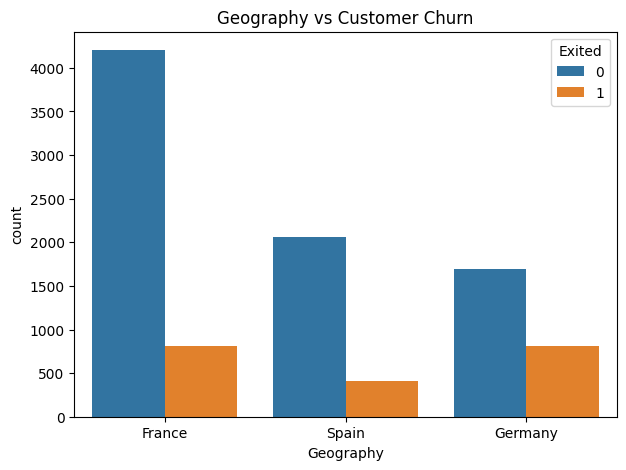

In [34]:
plt.figure(figsize=(7,5))

sns.countplot(x="Geography", hue="Exited", data=df_clean)

plt.title("Geography vs Customer Churn")

plt.show()

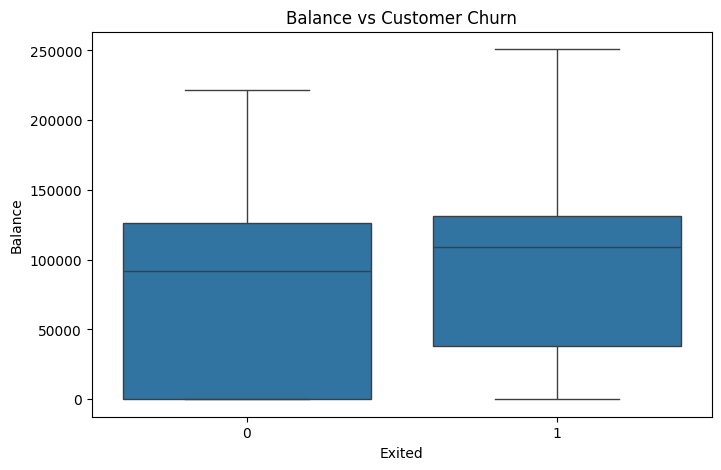

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Exited", y="Balance", data=df_clean)

plt.title("Balance vs Customer Churn")

plt.show()

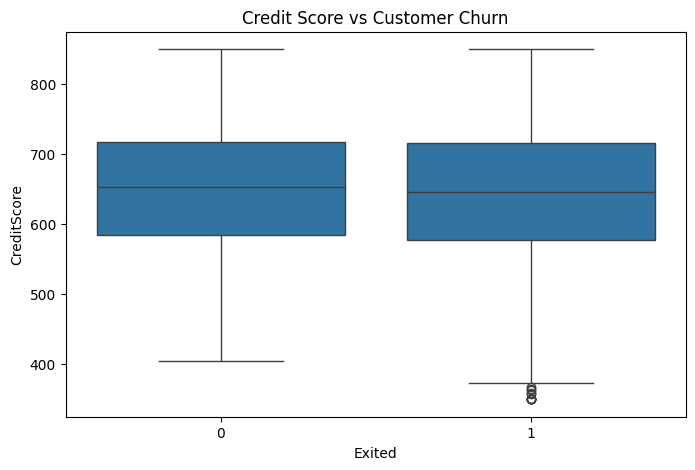

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Exited", y="CreditScore", data=df_clean)

plt.title("Credit Score vs Customer Churn")

plt.show()

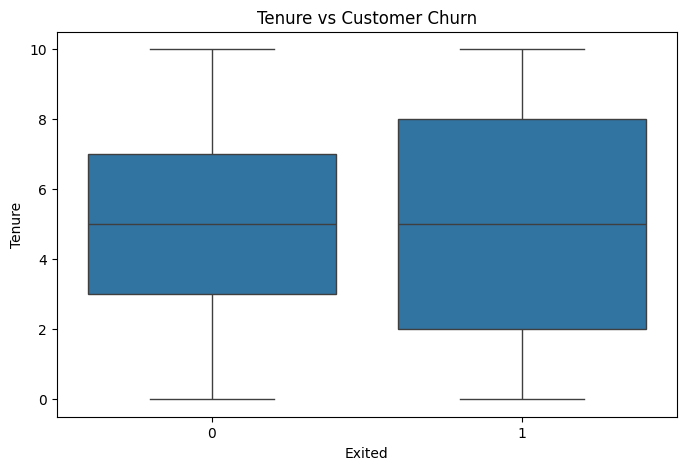

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Exited", y="Tenure", data=df_clean)

plt.title("Tenure vs Customer Churn")

plt.show()

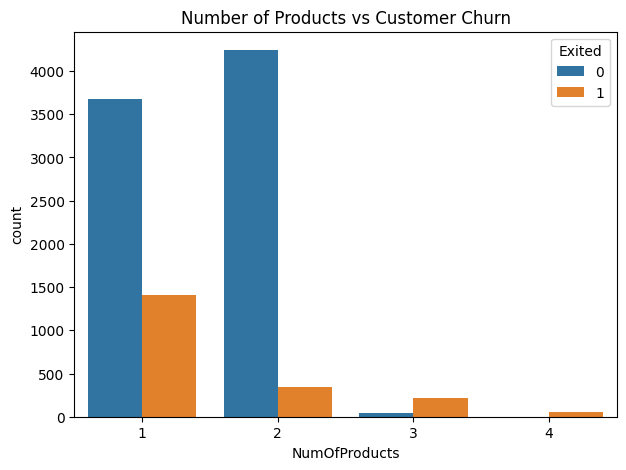

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(x="NumOfProducts", hue="Exited", data=df_clean)

plt.title("Number of Products vs Customer Churn")

plt.show()

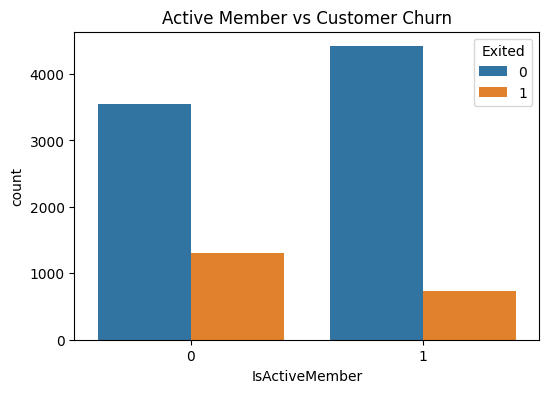

In [39]:
plt.figure(figsize=(6,4))

sns.countplot(x="IsActiveMember", hue="Exited", data=df_clean)

plt.title("Active Member vs Customer Churn")

plt.show()

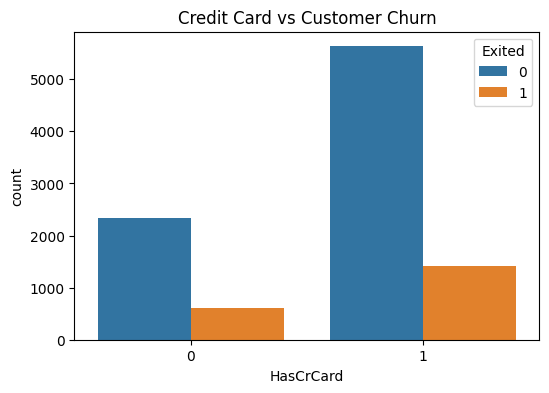

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(x="HasCrCard", hue="Exited", data=df_clean)

plt.title("Credit Card vs Customer Churn")

plt.show()

In [41]:
df_corr = df_clean.copy()

df_corr["Gender"] = df_corr["Gender"].map({"Male":1, "Female":0})

df_corr = pd.get_dummies(df_corr, columns=["Geography"], drop_first=True)

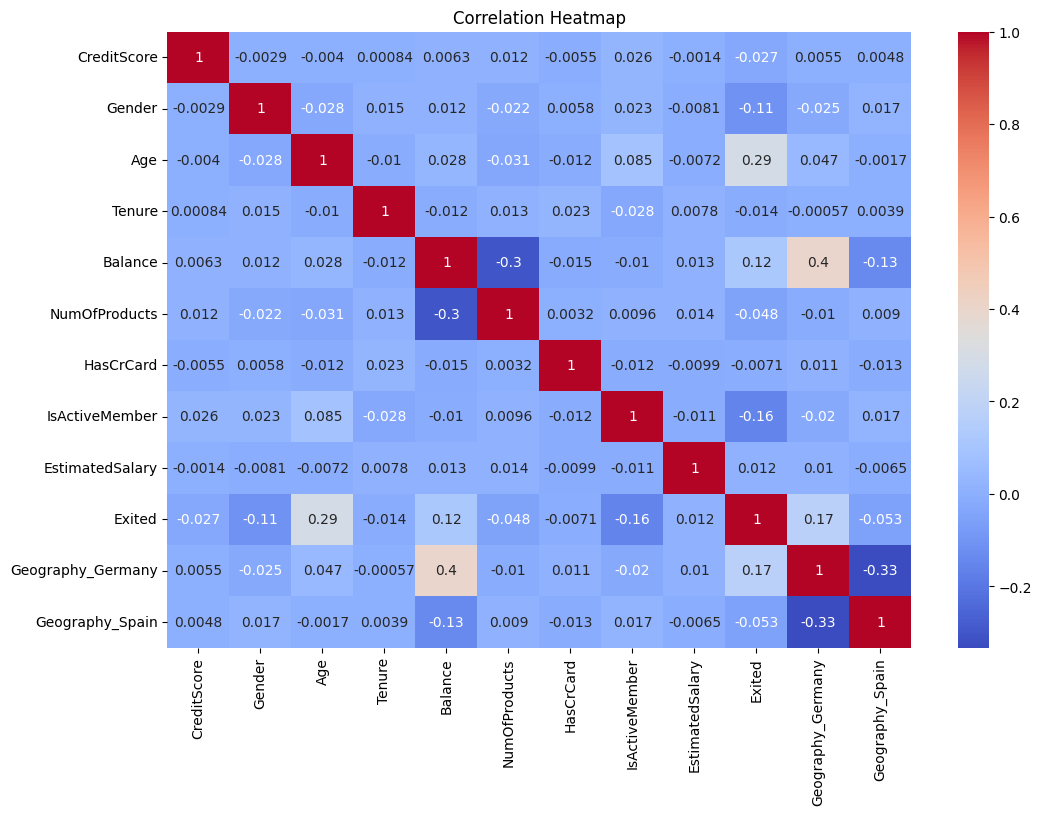

In [42]:
plt.figure(figsize=(12,8))

sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [43]:
df_fe = df_clean.copy()

In [44]:
df_fe["BalanceSalaryRatio"] = df_fe["Balance"] / (df_fe["EstimatedSalary"] + 1)

In [45]:
df_fe["ProductDensity"] = df_fe["NumOfProducts"] / (df_fe["Tenure"] + 1)

In [46]:
df_fe["AgeTenure"] = df_fe["Age"] * df_fe["Tenure"]

In [47]:
df_fe["EngagementScore"] = (
    df_fe["HasCrCard"] +
    df_fe["IsActiveMember"] +
    df_fe["NumOfProducts"]
)

In [48]:
df_fe.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,AgeTenure,EngagementScore
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,84,3
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,41,2
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,336,4
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,39,2
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,86,3


In [49]:
df_fe.shape

(10000, 15)

In [50]:
df_fe.isnull().sum()

CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
BalanceSalaryRatio    0
ProductDensity        0
AgeTenure             0
EngagementScore       0
dtype: int64

In [51]:
X = df_fe.drop("Exited", axis=1)

y = df_fe["Exited"]

In [52]:
print(X.head())

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  BalanceSalaryRatio  \
0          1               1        101348.88            0.000000   
1          0               1        112542.58            0.744670   
2          1               0        113931.57            1.401362   
3          0               0         93826.63            0.000000   
4          1               1         79084.10            1.587035   

   ProductDensity  AgeTenure  EngagementScore  
0        0.333333         84                3  
1        0.500000         41          

In [53]:
print(y.head())

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64


In [54]:
print(X.shape)

(10000, 14)


In [55]:
print(y.shape)

(10000,)


In [56]:
X.dtypes

CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
BalanceSalaryRatio    float64
ProductDensity        float64
AgeTenure               int64
EngagementScore         int64
dtype: object

In [57]:
X = pd.get_dummies(
    X,
    columns=["Geography", "Gender"],
    drop_first=True
)

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [59]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 15)
(2000, 15)
(8000,)
(2000,)


In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:
scaler = StandardScaler()

In [62]:
X_train_scaled = scaler.fit_transform(X_train)

In [63]:
X_test_scaled = scaler.transform(X_test)

In [64]:
print(X_train_scaled.shape)

print(X_test_scaled.shape)

(8000, 15)
(2000, 15)


In [65]:
from sklearn.linear_model import LogisticRegression

In [66]:
lr_model = LogisticRegression(random_state=42)

In [67]:
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [68]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [69]:
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [71]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.8085
Precision: 0.5952380952380952
Recall   : 0.18427518427518427
F1 Score : 0.28142589118198874
ROC AUC  : 0.7742025538635708


In [72]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.60      0.18      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [73]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[1542   51]
 [ 332   75]]


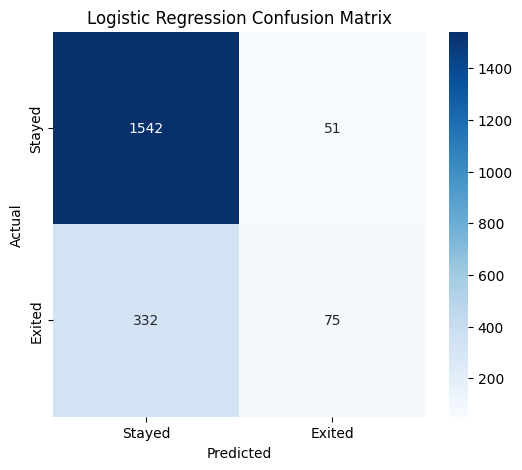

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed","Exited"],
    yticklabels=["Stayed","Exited"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [75]:
results = {}

results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1": f1_score(y_test, y_pred_lr),
    "ROC_AUC": roc_auc_score(y_test, y_prob_lr)
}

In [76]:
from sklearn.ensemble import GradientBoostingClassifier

In [77]:
import sys
import subprocess

subprocess.run([sys.executable, "-m", "pip", "install", "xgboost"])

CompletedProcess(args=['C:\\Users\\Gouri\\AppData\\Local\\Programs\\Python\\Python310\\python.exe', '-m', 'pip', 'install', 'xgboost'], returncode=0)

In [78]:
from xgboost import XGBClassifier

In [79]:
results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.8085,0.595238,0.184275,0.281426,0.774203


In [80]:
from sklearn.tree import DecisionTreeClassifier

In [81]:
dt_model = DecisionTreeClassifier(random_state=42)

In [82]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [83]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1": f1_score(y_test, y_pred_dt),
    "ROC_AUC": roc_auc_score(y_test, y_prob_dt)
}

print(results["Decision Tree"])

{'Accuracy': 0.7805, 'Precision': 0.4627906976744186, 'Recall': 0.48894348894348894, 'F1': 0.4755077658303465, 'ROC_AUC': 0.671967036373816}


In [85]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.8085,0.595238,0.184275,0.281426,0.774203
Decision Tree,0.7805,0.462791,0.488943,0.475508,0.671967


In [86]:
from sklearn.ensemble import RandomForestClassifier


In [87]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [88]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [89]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [90]:
results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC_AUC": roc_auc_score(y_test, y_prob_rf)
}

print(results["Random Forest"])

{'Accuracy': 0.865, 'Precision': 0.7818930041152263, 'Recall': 0.4668304668304668, 'F1': 0.5846153846153846, 'ROC_AUC': 0.8535214721655401}


In [91]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.8085,0.595238,0.184275,0.281426,0.774203
Decision Tree,0.7805,0.462791,0.488943,0.475508,0.671967
Random Forest,0.8650,0.781893,0.466830,0.584615,0.853521


In [92]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

In [93]:
results["Gradient Boosting"] = {
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb),
    "Recall": recall_score(y_test, y_pred_gb),
    "F1": f1_score(y_test, y_pred_gb),
    "ROC_AUC": roc_auc_score(y_test, y_prob_gb)
}

print(results["Gradient Boosting"])

{'Accuracy': 0.871, 'Precision': 0.7944664031620553, 'Recall': 0.49385749385749383, 'F1': 0.6090909090909091, 'ROC_AUC': 0.8669100533507313}


In [94]:
results_df = pd.DataFrame(results).T

results_df.sort_values(by="ROC_AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC_AUC
Gradient Boosting,0.8710,0.794466,0.493857,0.609091,0.866910
Random Forest,0.8650,0.781893,0.466830,0.584615,0.853521
Logistic Regression,0.8085,0.595238,0.184275,0.281426,0.774203
Decision Tree,0.7805,0.462791,0.488943,0.475508,0.671967


In [95]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
1                  Age    0.381661
4        NumOfProducts    0.289727
6       IsActiveMember    0.098882
3              Balance    0.062397
12   Geography_Germany    0.052418
11     EngagementScore    0.030995
8   BalanceSalaryRatio    0.025045
0          CreditScore    0.017139
7      EstimatedSalary    0.014191
14         Gender_Male    0.013554
10           AgeTenure    0.008885
9       ProductDensity    0.003317
2               Tenure    0.000758
13     Geography_Spain    0.000600
5            HasCrCard    0.000432


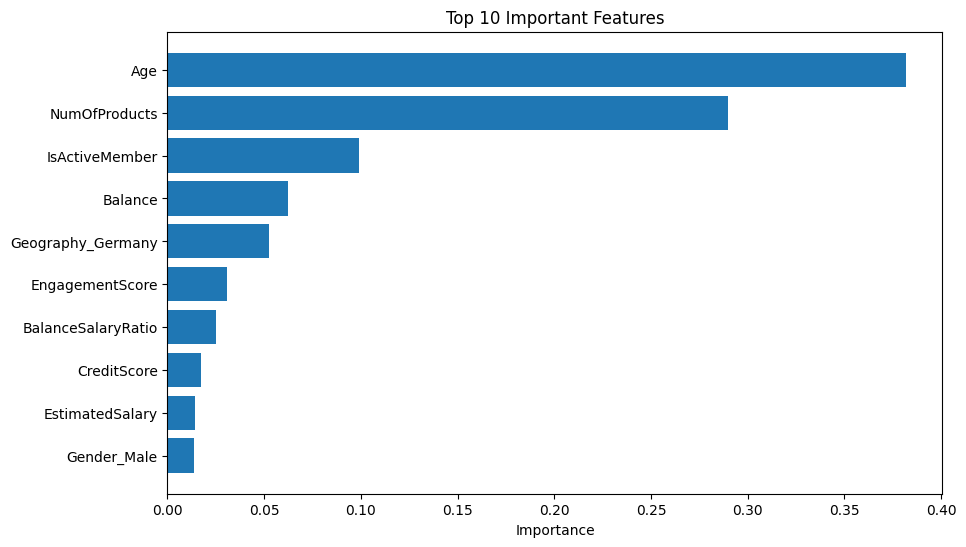

In [96]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

In [97]:
import os

os.makedirs("models", exist_ok=True)

In [98]:
import joblib

joblib.dump(gb_model, "models/churn_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(X.columns.tolist(), "models/model_columns.pkl")

['models/model_columns.pkl']

In [99]:
joblib.dump(X.columns.tolist(), "models/model_columns.pkl")

['models/model_columns.pkl']

In [2]:
import joblib

model_columns = joblib.load("models/model_columns.pkl")

print("Model columns:")
print(model_columns)

print("\nNumber of columns:", len(model_columns))

Model columns:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio', 'ProductDensity', 'AgeTenure', 'EngagementScore', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

Number of columns: 15


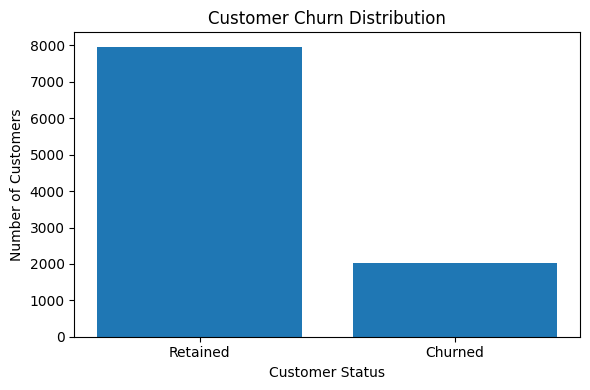

In [12]:
import matplotlib.pyplot as plt

churn_counts = df["Exited"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Retained", "Churned"],
    
    [churn_counts.get(0, 0), churn_counts.get(1, 0)]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig("churn_distribution.png", dpi=300)
plt.show()

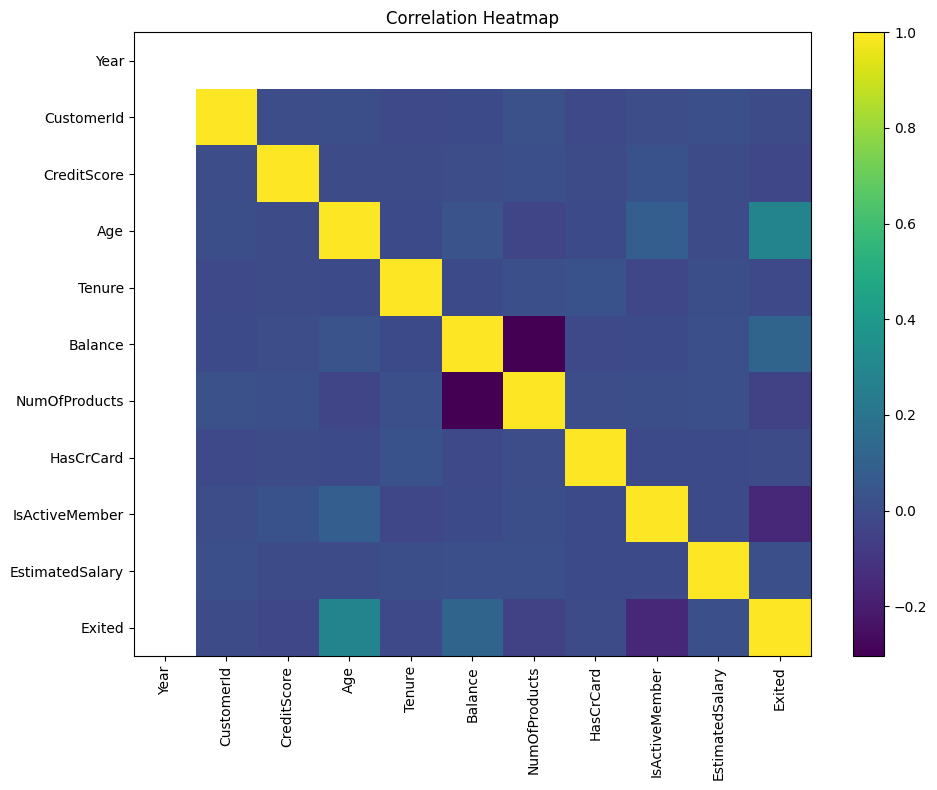

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.imshow(
    numeric_df.corr(),
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(numeric_df.columns)),
    numeric_df.columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_df.columns)),
    numeric_df.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

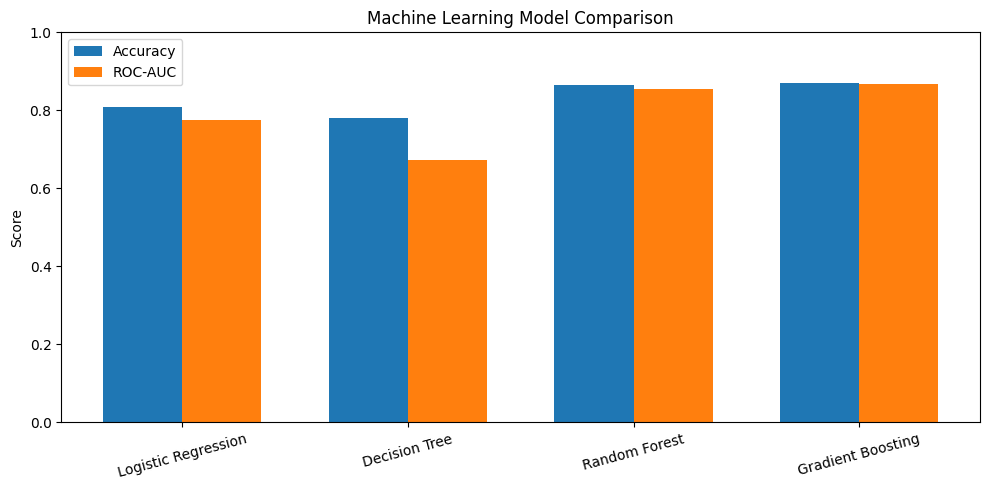

In [15]:
import matplotlib.pyplot as plt

results = {
    "Logistic Regression": {
        "Accuracy": 0.8085,
        "ROC-AUC": 0.774203
    },
    "Decision Tree": {
        "Accuracy": 0.7805,
        "ROC-AUC": 0.671967
    },
    "Random Forest": {
        "Accuracy": 0.8650,
        "ROC-AUC": 0.853521
    },
    "Gradient Boosting": {
        "Accuracy": 0.8710,
        "ROC-AUC": 0.866910
    }
}

models = list(results.keys())

accuracy = [
    results[m]["Accuracy"]
    for m in models
]

roc_auc = [
    results[m]["ROC-AUC"]
    for m in models
]

x = range(len(models))

width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    [i - width/2 for i in x],
    accuracy,
    width,
    label="Accuracy"
)

plt.bar(
    [i + width/2 for i in x],
    roc_auc,
    width,
    label="ROC-AUC"
)

plt.xticks(x, models, rotation=15)

plt.ylabel("Score")

plt.title("Machine Learning Model Comparison")

plt.legend()

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig("model_comparison.png", dpi=300)

plt.show()

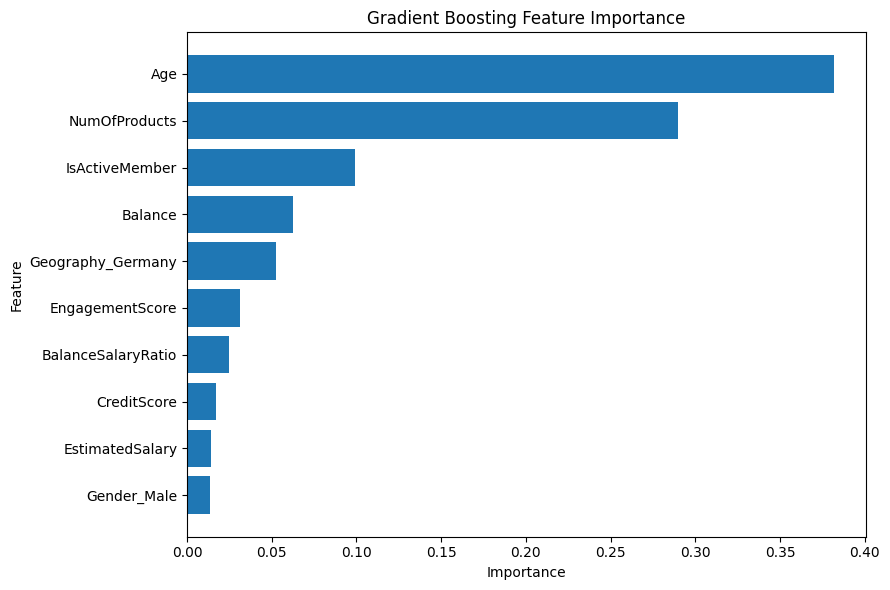

In [16]:
import matplotlib.pyplot as plt

feature_importance = {
    "Age": 0.381661,
    "NumOfProducts": 0.289727,
    "IsActiveMember": 0.098882,
    "Balance": 0.062397,
    "Geography_Germany": 0.052418,
    "EngagementScore": 0.030995,
    "BalanceSalaryRatio": 0.025045,
    "CreditScore": 0.017139,
    "EstimatedSalary": 0.014191,
    "Gender_Male": 0.013554
}

features = list(feature_importance.keys())
importance = list(feature_importance.values())

plt.figure(figsize=(9, 6))

plt.barh(
    features[::-1],
    importance[::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()